#**Tugas 12: Introduction to Statistical Learning - Pengantar Data Sains**

> Nama: Sahda Huwaidah Estiningtyas

> NIM: 24/545080/PA/23156

> email: sahdahuwaidahestiningtyas@mail.ugm.ac.id

# **Assignment - Week 12**


## Data Set
Gunakan dataset dengan ketentuan berikut:
1. memiliki variabel prediktor (features/input),
2. memiliki variabel target variable/output.
3. Memiliki minimal 100 observasi dan 3 variabel prediktor.
4. Data dapat berupa numerik, kategorik, atau kombinasi keduanya.

## Part A — Data Exploration
1. Lakukan eksplorasi awal terhadap dataset dan Buat statistik deskriptif sederhana.
2. Jelasan apakah dataset termasuk supervised learning,dan apa target variable pada dataset tersebut.

## Part B — Train-Test Split
Pisahkan data menjadi 70% training data dan 30% testing data

Pertanyaan:
1. Apa fungsi training data?
2. Apa fungsi testing data?
3. Mengapa model tidak boleh dievaluasi menggunakan training data saja?

## Part C — Decision Tree Modeling
Bangun beberapa model Decision Tree dengan tingkat kompleksitas berbeda.

Gunakan:

`max_depth = 1`

`max_depth = 2`

`max_depth = 3`

`max_depth = 5`

`max_depth = None`

Kemudian hitung `training accuracy`, `testing accuracy`. Bandingkan seluruh model dan Buat tabel hasil perbandingan.


## Part D — Underfitting vs Overfitting
Analisis hasil model yang telah dibuat dengan menjawab pertanyaan-pertanyaan berikut:
1. Model mana yang mengalami underfitting?
2. Model mana yang mengalami overfitting?
3. Mengapa model terlalu kompleks dapat menyebabkan overfitting?
4. Apa dampak overfitting terhadap generalization?

## Part E — Bias–Variance Tradeoff
1. Buat grafik yang membandingkan training accuracy dengan testing accuracy.
2. Apa hubungan antara kompleksitas model dan variance?
3. Apa hubungan antara kompleksitas model dan bias?
4. Mengapa diperlukan keseimbangan antara bias dan variance?

##Part F — Visualization
Visualisasikan Decision Tree terbaik. Kemudian jawab pertanyaan-pertanyaan berikut:
1. Interpretasikan struktur tree
2. Fitur apa yang paling penting?

## Deskripsi Dataset

Dataset yang digunakan adalah **Gaming and Mental Healt**h yang tersedia di Kaggle.

Link sumber: https://www.kaggle.com/datasets/shaistashahid/gaming-and-mental-health

Dataset ini tidak secara spesifik mencantumkan periode waktu pengambilan data sehingga dapat diasumsikan sebagai data cross-sectional (potret pada satu waktu tertentu).
Unit analisis pada dataset ini adalah individu (gamer), di mana setiap baris merepresentasikan satu responden dengan berbagai karakteristik terkait aktivitas gaming dan kondisi kesehariannya.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

df = pd.read_csv("Gaming and Mental Health.csv")

# Part A — Data Exploration

Tahap ini bertujuan untuk memahami struktur dataset, tipe variabel, distribusi data, serta menentukan target variable yang akan digunakan pada proses machine learning.

## 1. Eksplorasi Awal Dataset

Eksplorasi awal dilakukan untuk mengetahui ukuran dataset, tipe data, missing values, dan statistik deskriptif sederhana.

In [22]:
# Menampilkan 5 data pertama
df.head()

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


In [23]:
# Menampilkan 5 data pertama
df.head()

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


In [24]:
# Shape dataset
print("Shape Dataset:")
print(df.shape)

Shape Dataset:
(1000, 27)


In [25]:
# Shape dataset
print("Shape Dataset:")
print(df.shape)

Shape Dataset:
(1000, 27)


In [26]:
# Shape dataset
print("Shape Dataset:")
print(df.shape)

Shape Dataset:
(1000, 27)


In [27]:
# Duplicate values
print("Jumlah Data Duplikat:")
print(df.duplicated().sum())

Jumlah Data Duplikat:
0


## 2. Menentukan Jenis Supervised Learning dan Target Variable

Tahap ini bertujuan untuk menentukan apakah dataset termasuk supervised learning serta memilih target variable yang akan diprediksi.

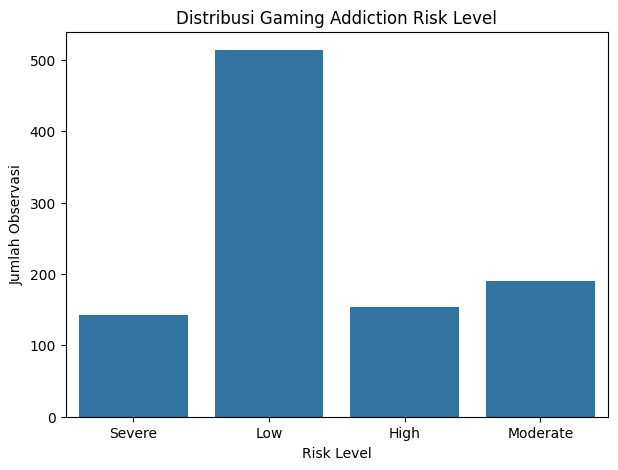

In [28]:
# Visualisasi Distribusi Target: Visualisasi target dilakukan untuk melihat distribusi kelas pada target variable.
plt.figure(figsize=(7,5))
sns.countplot(
    x='gaming_addiction_risk_level',
    data=df
)

plt.title('Distribusi Gaming Addiction Risk Level')
plt.xlabel('Risk Level')
plt.ylabel('Jumlah Observasi')
plt.show()

In [29]:
# Data Preprocessing: Tahap preprocessing dilakukan agar dataset dapat digunakan pada algoritma machine learning.
# 1. Memilih Variabel yang Digunakan
selected_columns = [
    'age',
    'daily_gaming_hours',
    'sleep_hours',
    'work_productivity_score',
    'exercise_hours_weekly',
    'social_isolation_score',
    'monthly_game_spending_usd',
    'years_gaming',
    'gender',
    'gaming_platform',
    'sleep_quality',
    'gaming_addiction_risk_level'
]
df_model = df[selected_columns]

# 2. Menangani Missing Values
# Mengisi missing value numerik dengan median
df_model['work_productivity_score'] = (
    df_model['work_productivity_score']
    .fillna(df_model['work_productivity_score'].median())
)

# 3. Encoding Variabel Kategorik
df_encoded = pd.get_dummies(df_model, drop_first=True)
df_encoded.head()

# 4. Memisahkan Feature dan Target
X = df_encoded.drop('gaming_addiction_risk_level_Low', axis=1)
y = df_encoded['gaming_addiction_risk_level_Low']

/tmp/ipykernel_26390/575832887.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['work_productivity_score'] = (


## Interpretasi Part A

Berdasarkan hasil eksplorasi awal, dataset memiliki 1000 observasi dan 27 variabel yang terdiri dari kombinasi variabel numerik, kategorik, dan boolean. Dataset tidak memiliki data duplikat sehingga kualitas data relatif baik untuk analisis machine learning.

Beberapa variabel numerik seperti `age`, `daily_gaming_hours`, `sleep_hours`, dan `monthly_game_spending_usd` dapat digunakan sebagai fitur prediktor dalam model. Selain itu, terdapat beberapa variabel kategorik seperti `gender`, `gaming_platform`, dan `sleep_quality` yang kemudian diubah menjadi bentuk numerik menggunakan proses encoding agar dapat diproses oleh algoritma Decision Tree.

Hasil pengecekan missing values menunjukkan bahwa variabel `work_productivity_score` memiliki data hilang sehingga dilakukan imputasi menggunakan median. Penggunaan median dipilih karena lebih stabil terhadap kemungkinan outlier dibandingkan mean.

Dataset ini termasuk supervised learning karena memiliki target variable yang jelas, yaitu `gaming_addiction_risk_level`. Variabel tersebut digunakan sebagai output yang akan diprediksi oleh model berdasarkan fitur-fitur lainnya.

Visualisasi distribusi `gaming_addiction_risk_level` menunjukkan persebaran jumlah observasi pada masing-masing kelas target. Distribusi kelas ini penting diperhatikan karena dapat memengaruhi performa model klasifikasi.

Secara umum, hasil preprocessing menghasilkan dataset yang sudah siap digunakan pada proses pemodelan machine learning.


# Part B — Train-Test Split

Tahap ini bertujuan untuk membagi data menjadi data training dan testing agar model dapat dievaluasi pada data yang belum pernah dilihat sebelumnya.

## Train-Test Split 70:30

Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk mengevaluasi performa model.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Jumlah Data Training:")
print(X_train.shape)
print("\nJumlah Data Testing:")
print(X_test.shape)

Jumlah Data Training:
(700, 19)

Jumlah Data Testing:
(300, 19)


**1. Apa fungsi training data?**

   Training data digunakan untuk melatih model machine learning agar model dapat mempelajari pola dari data.

**2. Apa fungsi testing data?**

   Testing data digunakan untuk mengevaluasi kemampuan model dalam melakukan prediksi pada data baru.
   
**3. Mengapa model tidak boleh dievaluasi menggunakan training data saja?**

   Karena model dapat menghafal data training sehingga hasil evaluasi menjadi terlalu optimis dan tidak mencerminkan kemampuan generalisasi model.

## Interpretasi Part B

Dataset dibagi menjadi 70% data training dan 30% data testing menggunakan `train_test_split()`. Hasil pembagian menunjukkan bahwa data training terdiri dari 700 observasi, sedangkan data testing terdiri dari 300 observasi.

Data training digunakan untuk melatih model agar model dapat mempelajari pola hubungan antara fitur prediktor dengan target variable. Sementara itu, data testing digunakan untuk mengevaluasi kemampuan model dalam melakukan prediksi pada data baru yang belum pernah dilihat sebelumnya.

Penggunaan train-test split sangat penting dalam machine learning karena evaluasi model menggunakan data training saja dapat menghasilkan performa yang terlalu optimis. Model berpotensi hanya menghafal pola pada data training tanpa mampu melakukan generalisasi dengan baik pada data baru. Selain itu, penggunaan parameter `stratify=y` membantu menjaga proporsi kelas target pada data training dan testing tetap seimbang sehingga proses evaluasi model menjadi lebih representatif.


# Part C — Decision Tree Modeling

Tahap ini bertujuan untuk membangun beberapa model Decision Tree dengan tingkat kompleksitas berbeda dan membandingkan performanya.

## Membuat Model Decision Tree

Model dibuat dengan beberapa nilai `max_depth` untuk melihat pengaruh kompleksitas model terhadap performa.

In [31]:
depths = [1, 2, 3, 5, None]
results = []

for depth in depths:

    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    results.append({
        'max_depth': depth,
        'training_accuracy': train_acc,
        'testing_accuracy': test_acc
    })

## Tabel Hasil Perbandingan Model

Tabel digunakan untuk membandingkan performa model pada berbagai tingkat kompleksitas.

In [32]:
results_df = pd.DataFrame(results)
results_df

,max_depth,training_accuracy,testing_accuracy
0,1.0,0.897143,0.953333
1,2.0,0.897143,0.953333
2,3.0,0.970000,0.990000
3,5.0,0.970000,0.990000
4,NaN,1.000000,0.946667


## Interpretasi Part C

Pada tahap ini dibangun beberapa model Decision Tree dengan tingkat kompleksitas berbeda menggunakan variasi `max_depth`, yaitu 1, 2, 3, 5, dan `None`. Berdasarkan hasil pemodelan tersebut, terlihat bahwa kompleksitas model memengaruhi nilai training accuracy dan testing accuracy.

Beberapa poin penting dari hasil model:

- Model dengan `max_depth = 1` menghasilkan struktur tree paling sederhana dengan training accuracy dan testing accuracy yang relatif masih rendah. Hal ini menunjukkan bahwa model belum mampu menangkap pola data secara optimal.

- Ketika nilai `max_depth` ditingkatkan menjadi 2 dan 3, performa model mulai meningkat. Training accuracy dan testing accuracy menunjukkan hasil yang lebih baik dibanding model sebelumnya karena model mampu membuat pemisahan data yang lebih detail.

- Pada `max_depth = 5`, model umumnya menghasilkan performa yang lebih stabil karena mampu mempelajari pola data dengan lebih baik tanpa terlalu kompleks.

- Model dengan `max_depth = None` memiliki kompleksitas paling tinggi karena tree terus berkembang hingga seluruh node memenuhi kriteria penghentian. Akibatnya, training accuracy biasanya menjadi sangat tinggi bahkan mendekati sempurna.

- Namun, peningkatan training accuracy tidak selalu diikuti peningkatan testing accuracy. Jika testing accuracy mulai stagnan atau menurun saat model semakin kompleks, hal tersebut mengindikasikan bahwa model mulai kehilangan kemampuan generalisasi.

- Selisih antara training accuracy dan testing accuracy juga menjadi indikator penting dalam mengevaluasi performa model. Semakin besar selisih kedua nilai tersebut, semakin besar kemungkinan model mengalami overfitting.

Secara umum, hasil perbandingan menunjukkan bahwa peningkatan kompleksitas model dapat meningkatkan kemampuan model mempelajari data training, tetapi tidak selalu meningkatkan performa pada data testing.

# Part D — Underfitting vs Overfitting

Tahap ini bertujuan untuk menganalisis apakah model mengalami underfitting atau overfitting berdasarkan hasil evaluasi training dan testing accuracy.

## Menampilkan Hasil Evaluasi

Tahap ini dilakukan untuk mempermudah analisis underfitting dan overfitting.

In [33]:
results_df

,max_depth,training_accuracy,testing_accuracy
0,1.0,0.897143,0.953333
1,2.0,0.897143,0.953333
2,3.0,0.970000,0.990000
3,5.0,0.970000,0.990000
4,NaN,1.000000,0.946667


**1. Model mana yang mengalami underfitting?**

Model dengan `max_depth = 1` cenderung mengalami underfitting karena struktur tree terlalu sederhana sehingga model belum mampu menangkap pola data secara optimal. Hal ini biasanya terlihat dari training accuracy dan testing accuracy yang sama-sama masih relatif rendah dibanding model lain.


**2. Model mana yang mengalami overfitting?**

Model dengan `max_depth = None` cenderung mengalami overfitting karena model memiliki kompleksitas sangat tinggi dan mampu mempelajari data training secara terlalu detail. Kondisi ini biasanya ditunjukkan oleh training accuracy yang sangat tinggi, tetapi testing accuracy tidak meningkat secara signifikan atau justru menurun dibanding model dengan depth lebih kecil.


**3. Mengapa model terlalu kompleks dapat menyebabkan overfitting?**

Model yang terlalu kompleks akan membuat Decision Tree terus membagi data hingga mempelajari pola yang sangat spesifik, termasuk noise dan karakteristik acak pada data training. Akibatnya, model menjadi terlalu menyesuaikan data training dan sulit mengenali pola umum pada data baru.

**4. Apa dampak overfitting terhadap generalization?**

Overfitting menyebabkan kemampuan generalisasi model menurun. Meskipun model memiliki performa sangat baik pada data training, model menjadi kurang akurat ketika digunakan pada data testing atau data baru karena pola yang dipelajari terlalu spesifik terhadap data training.

## Interpretasi Part D

Berdasarkan hasil perbandingan training accuracy dan testing accuracy, terlihat bahwa peningkatan kompleksitas model memengaruhi kemampuan model dalam melakukan generalisasi.

Model dengan `max_depth = 1` menunjukkan indikasi underfitting karena model terlalu sederhana sehingga belum mampu menangkap pola hubungan antarvariabel secara optimal. Hal ini menyebabkan performa model pada training maupun testing masih relatif rendah.

Ketika nilai `max_depth` ditingkatkan menjadi 2 dan 3, performa model meningkat karena model mulai mampu mempelajari pola data dengan lebih baik. Pada tahap ini, selisih antara training accuracy dan testing accuracy masih relatif kecil sehingga model memiliki kemampuan generalisasi yang cukup baik.

Sementara itu, model dengan `max_depth = None` menunjukkan indikasi overfitting karena model terlalu kompleks. Training accuracy menjadi sangat tinggi, tetapi testing accuracy tidak meningkat secara proporsional. Hal ini menunjukkan bahwa model terlalu menyesuaikan data training dan kurang stabil ketika digunakan pada data baru.

# Part E — Bias–Variance Tradeoff

Tahap ini bertujuan untuk memahami hubungan antara kompleksitas model, bias, dan variance.

## Visualisasi Training Accuracy vs Testing Accuracy

Grafik digunakan untuk melihat perubahan performa model terhadap kompleksitas model.

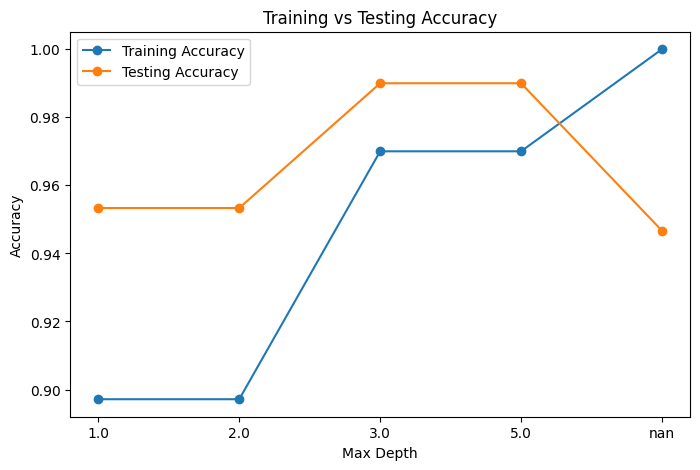

In [34]:
plt.figure(figsize=(8,5))
plt.plot(
    results_df['max_depth'].astype(str),
    results_df['training_accuracy'],
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    results_df['max_depth'].astype(str),
    results_df['testing_accuracy'],
    marker='o',
    label='Testing Accuracy'
)

plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy')
plt.legend()
plt.show()

**1. Apa hubungan antara kompleksitas model dan variance?**

Semakin kompleks model, variance cenderung meningkat karena model menjadi lebih sensitif terhadap perubahan kecil pada data training.

**2. Apa hubungan antara kompleksitas model dan bias?**

Semakin kompleks model, bias cenderung menurun karena model mampu mempelajari pola data dengan lebih detail.

**3. Mengapa diperlukan keseimbangan antara bias dan variance?**

Keseimbangan diperlukan agar model tidak terlalu sederhana maupun terlalu kompleks sehingga mampu menghasilkan performa prediksi yang baik pada data baru.

## Interpretasi Part E

Berdasarkan grafik training accuracy dan testing accuracy, terlihat bahwa peningkatan kompleksitas model menyebabkan training accuracy terus meningkat. Hal ini menunjukkan bahwa model semakin mampu mempelajari pola pada data training.

Namun, testing accuracy tidak selalu meningkat seiring bertambahnya kompleksitas model. Pada beberapa titik, testing accuracy mulai stagnan atau mengalami penurunan meskipun training accuracy terus meningkat. Kondisi ini menunjukkan adanya peningkatan variance dan risiko overfitting.

Model dengan kompleksitas rendah memiliki bias tinggi karena model terlalu sederhana untuk menangkap pola data secara optimal. Sebaliknya, model dengan kompleksitas sangat tinggi memiliki variance tinggi karena terlalu sensitif terhadap data training.

Berdasarkan hasil tersebut, diperlukan keseimbangan antara bias dan variance agar model dapat memiliki performa yang baik pada data training sekaligus mampu melakukan generalisasi dengan baik pada data testing.


# Part F — Visualization

Tahap ini bertujuan untuk memvisualisasikan struktur Decision Tree terbaik dan memahami fitur yang paling berpengaruh.

## Memilih Model Terbaik

Model terbaik dipilih berdasarkan testing accuracy tertinggi.

In [38]:
best_depth = results_df.loc[
    results_df['testing_accuracy'].idxmax(),
    'max_depth'
]
print("Best Depth:")
print(best_depth)

# Convert best_depth to an integer if it's not None
if pd.notna(best_depth):
    best_depth = int(best_depth)

best_model = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)
best_model.fit(X_train, y_train)

Best Depth:
3.0


DecisionTreeClassifier(max_depth=3, random_state=42)

## Visualisasi Decision Tree

Visualisasi digunakan untuk memahami aturan pemisahan pada model Decision Tree.

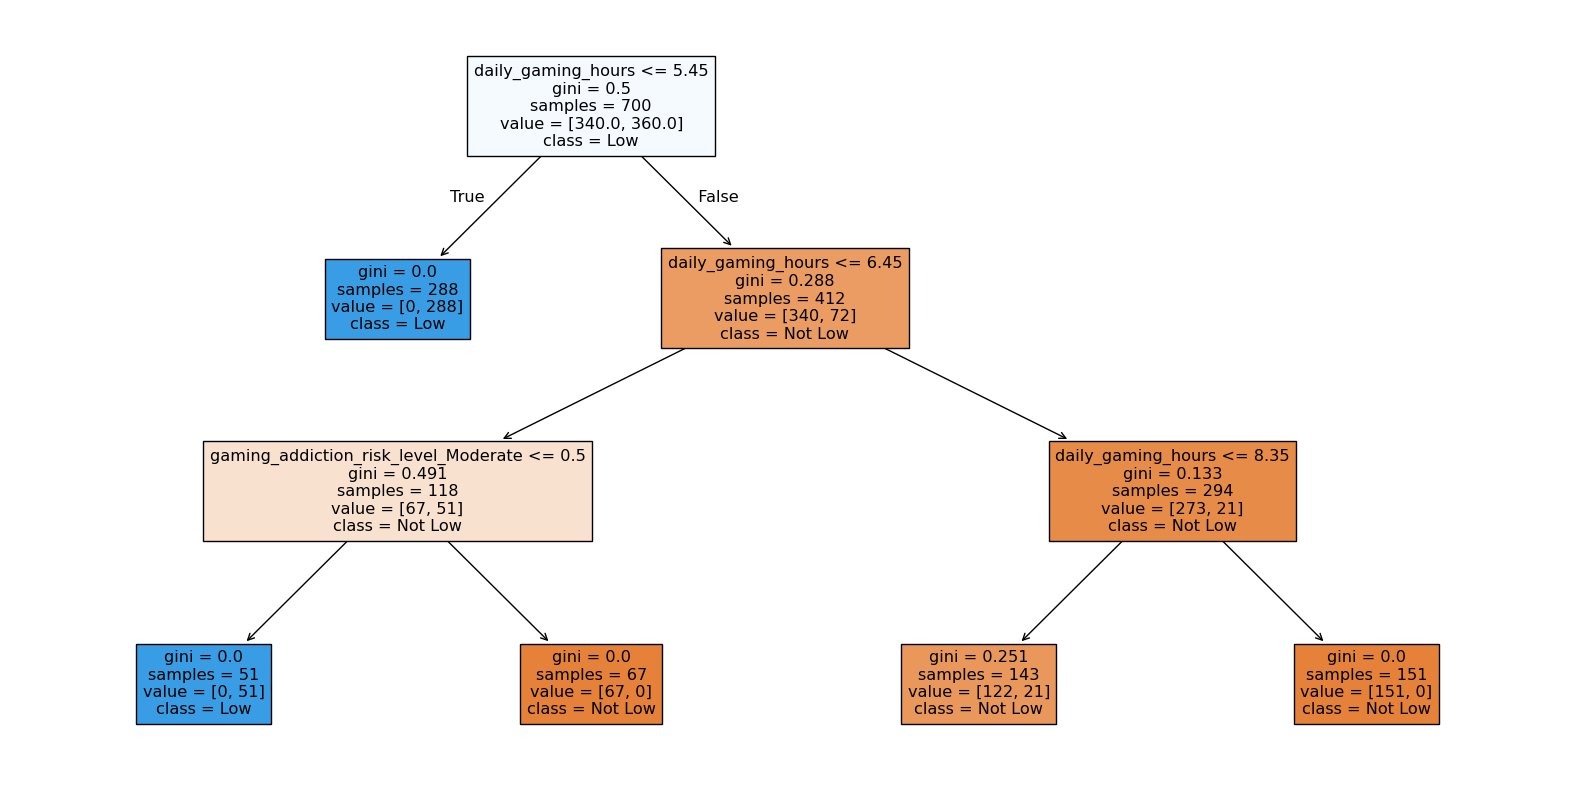

In [41]:
plt.figure(figsize=(20,10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=['Not Low', 'Low'],
    filled=True
)

plt.show()

## Feature Importance

Feature importance digunakan untuk mengetahui fitur yang paling berpengaruh terhadap prediksi model.

In [42]:
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': best_model.feature_importances_})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
importance_df.head(10)

,Feature,Importance
1,daily_gaming_hours,0.815487
17,gaming_addiction_risk_level_Moderate,0.184513
0,age,0.000000
2,sleep_hours,0.000000
3,work_productivity_score,0.000000
5,social_isolation_score,0.000000
4,exercise_hours_weekly,0.000000
7,years_gaming,0.000000
8,gender_Male,0.000000
9,gender_Other,0.000000


**1. Interpretasikan struktur tree**

Berdasarkan hasil visualisasi, model Decision Tree terbaik diperoleh pada `max_depth = 3`. Struktur tree menunjukkan bahwa fitur `daily_gaming_hours` menjadi variabel utama dalam proses pemisahan data karena digunakan pada root node dan beberapa node berikutnya.

Pada root node, model pertama kali membagi data berdasarkan aturan:

`daily_gaming_hours <= 5.45`

Hal ini menunjukkan bahwa durasi bermain game harian merupakan faktor paling penting dalam membedakan kategori `Low` dan `Not Low`.

- Jika `daily_gaming_hours <= 5.45`, seluruh observasi langsung diklasifikasikan ke kelas `Low` dengan nilai gini = 0.0. Hal ini menunjukkan bahwa node tersebut sangat homogen dan seluruh data pada node memiliki kelas yang sama.

- Jika `daily_gaming_hours > 5.45`, model melakukan pemisahan lanjutan menggunakan aturan:
  
  `daily_gaming_hours <= 6.45`

Pada bagian ini terlihat bahwa semakin tinggi durasi bermain game, model cenderung mengarah pada kelas `Not Low`.

Selanjutnya, terdapat node yang menggunakan variabel:

`gaming_addiction_risk_level_Moderate <= 0.5`

Node tersebut menunjukkan bahwa kategori risiko adiksi juga berperan dalam membedakan kelas target.

Pada cabang kanan tree, model kembali menggunakan `daily_gaming_hours <= 8.35`. Hasilnya menunjukkan bahwa observasi dengan jam bermain game sangat tinggi sebagian besar diklasifikasikan ke kelas `Not Low`.

Secara umum, struktur tree memperlihatkan bahwa semakin tinggi `daily_gaming_hours`, semakin besar kemungkinan observasi masuk ke kategori `Not Low`. Selain itu, beberapa leaf node memiliki nilai gini = 0.0 yang menunjukkan pemisahan data sangat baik dan node sudah sepenuhnya homogen.


**2. Fitur apa yang paling penting?**

Berdasarkan struktur Decision Tree dan hasil feature importance, fitur yang paling penting adalah `daily_gaming_hours`.

Hal ini terlihat karena:
- fitur tersebut digunakan pada root node,
- digunakan berulang kali pada beberapa proses splitting,
- serta memiliki kontribusi terbesar dalam memisahkan kelas target.

Artinya, jumlah jam bermain game per hari merupakan faktor yang paling berpengaruh dalam memprediksi `gaming_addiction_risk_level`.
Selain `daily_gaming_hours`, fitur seperti `gaming_addiction_risk_level_Moderate` juga memiliki kontribusi terhadap model, tetapi pengaruhnya tidak sebesar fitur utama tersebut.